# Riemannian Optimization on Stiefel and Grassmann

On the Stiefel manifold $St(p,n)=\{X\in\mathbb R^{n\times p}:X^\top X=I\}$,
we optimize with tangent projection and retraction:
$$
X_{k+1} = \mathrm{qf}(X_k - \eta \,\mathrm{grad} f(X_k)).
$$
We solve a PCA-style objective under orthogonality constraints.

The Stiefel constraint $X^\top X=I$ is nonlinear, so Euclidean steps leave the feasible set. Riemannian optimization projects gradients onto the tangent space and retracts trial points back to the manifold. Orthogonality error and objective decay verify both geometry and optimization.


## Environment and Imports

We prepare numerical and visualization tools. The notebook writes a square representative image to
`python/riemannian-optimization-stiefel/snippet.png` so the search homepage can display it directly.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_DIR = Path("python/riemannian-optimization-stiefel") if Path("python/riemannian-optimization-stiefel").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)


## Core Construction

We now implement the main ideas for **Riemannian Optimization on Stiefel and Grassmann**, with equations and plots designed to expose both the model and the numerical behavior.


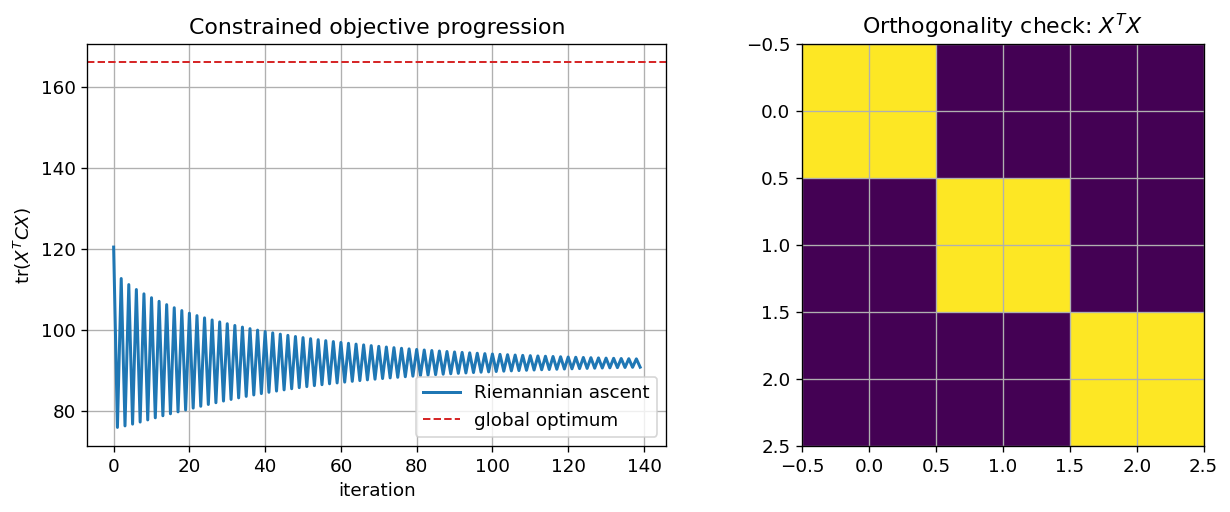

In [2]:
n, p = 20, 3
M = rng.normal(size=(n, n))
C = M.T @ M

Q, _ = np.linalg.qr(rng.normal(size=(n, p)))
X = Q
eta = 0.18
vals = []

for _ in range(140):
    # maximize tr(X^T C X) => minimize -tr(...)
    G = -2 * C @ X
    sym = 0.5 * (X.T @ G + G.T @ X)
    Rgrad = G - X @ sym  # tangent projection
    Y = X - eta * Rgrad
    X, _ = np.linalg.qr(Y)  # QR retraction
    vals.append(np.trace(X.T @ C @ X))

evals = np.linalg.eigvalsh(C)[::-1]
opt = np.sum(evals[:p])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(vals, lw=1.8, label="Riemannian ascent")
axes[0].axhline(opt, color="tab:red", ls="--", lw=1.2, label="global optimum")
axes[0].set_title("Constrained objective progression")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$\mathrm{tr}(X^T C X)$")
axes[0].legend()

axes[1].imshow(X.T @ X, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title(r"Orthogonality check: $X^T X$")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- P.-A. Absil, R. Mahony, R. Sepulchre, *Optimization Algorithms on Matrix Manifolds*, Princeton Univ. Press, 2008.
- N. Boumal, *An Introduction to Optimization on Smooth Manifolds*, Cambridge Univ. Press, 2023.
- A. Edelman, T. A. Arias, S. T. Smith, "The Geometry of Algorithms with Orthogonality Constraints", SIMAX, 1998.
